## Lab 4.1: Feature Matching - Exercises

1. Load images ```baker1.jpg``` and ```baker2.jpg``` and convert to grayscale.  Detect and match SIFT features between them and plot the results.

Try different settings for ```max_ratio``` to see which seems to produce the best set of matches.

*Note: Set ```only_matches=True``` for ```plot_matched_features``` so that the keypoints don't obscure the images.*

In [30]:
import matplotlib.pyplot as plt
import imageio
import numpy as np
from skimage import data
from skimage import transform
from skimage.color import rgb2gray
from skimage.feature import match_descriptors, plot_matched_features, SIFT

In [6]:
baker1 = rgb2gray(imageio.imread('baker1.jpg'))
baker2 = rgb2gray(imageio.imread('baker2.jpg'))
descriptor_extractor = SIFT()
descriptor_extractor.detect_and_extract(baker1)
keypoints1 = descriptor_extractor.keypoints
descriptors1 = descriptor_extractor.descriptors
descriptor_extractor.detect_and_extract(baker2)
keypoints2 = descriptor_extractor.keypoints
descriptors2 = descriptor_extractor.descriptors


C:\tmp\ipykernel_16104\4274007243.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  baker1 = rgb2gray(imageio.imread('baker1.jpg'))
C:\tmp\ipykernel_16104\4274007243.py:2: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  baker2 = rgb2gray(imageio.imread('baker2.jpg'))


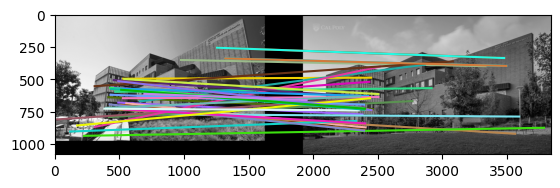

In [40]:
matches12 = match_descriptors(
    descriptors1, descriptors2, max_ratio=0.73, cross_check=True
)
fig,ax = plt.subplots()
plot_matched_features(baker1, baker2, keypoints0=keypoints1, keypoints1=keypoints2, matches=matches12, ax=ax, only_matches=True)

2. The image ```stereo.jpg``` contains a stereo pair image of an asteroid ([Bennu](https://www.asteroidmission.org/candidate-sample-sites/kingfisher/stereopair_kingfisher/)).  Load the image and split it into two images (```left``` and ```right```).  

Detect and match SIFT features between the two images and show the results.

In a rectified stereo pair, the movement between the images should be completely horizontal.  Filter out any matches that have vertical movement and show the results.

*Note: because there are a lot of matches, you might want to show only 10% or so of them.*

In [25]:
stereo = rgb2gray(imageio.imread('stereo.jpg'))
nrows, ncols = stereo.shape
left = stereo[:,ncols//2:]
right = stereo[:,:ncols//2]


C:\tmp\ipykernel_16104\798124095.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  stereo = rgb2gray(imageio.imread('stereo.jpg'))


In [26]:
descriptor_extractor_stereo = SIFT()
descriptor_extractor_stereo.detect_and_extract(left)
stereo_keypoints1 = descriptor_extractor_stereo.keypoints
stereo_descriptors1 = descriptor_extractor_stereo.descriptors
descriptor_extractor_stereo.detect_and_extract(right)
stereo_keypoints2 = descriptor_extractor_stereo.keypoints
stereo_descriptors2 = descriptor_extractor_stereo.descriptors

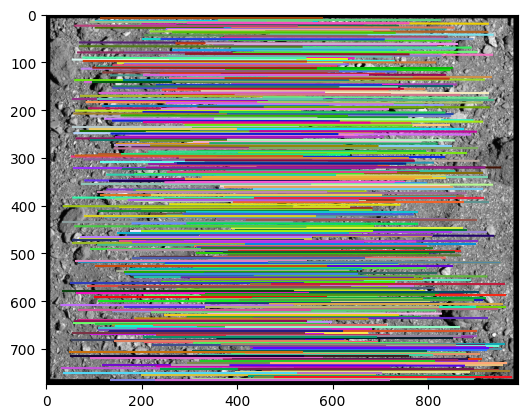

In [38]:
stereo_matches12 = match_descriptors(
    stereo_descriptors1, stereo_descriptors2, max_ratio=0.77, cross_check=True
)
y1 = stereo_keypoints1[stereo_matches12[:, 0], 0]
y2 = stereo_keypoints2[stereo_matches12[:, 1], 0]
stereo_matches12 = stereo_matches12[np.abs(y1 - y2) < 5]
fig,ax = plt.subplots()
plot_matched_features(left, right, keypoints0=stereo_keypoints1, keypoints1=stereo_keypoints2, matches=stereo_matches12[::10], ax=ax, only_matches=True)